The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


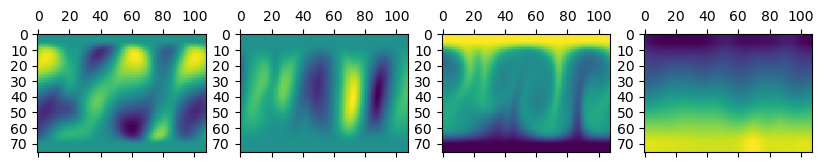

In [238]:
%load_ext autoreload
%autoreload 2

import torch
import matplotlib.pyplot as plt
import json
import tqdm

import pdes.bc as bc
import pdes.fdc2 as fdc
from conjugate_gradients import CG

torch.set_grad_enabled(False)
torch.set_default_device("cuda")

BOUNDARY_EXTENT = 6

data = json.load(open("data/rbc_data_1.json"))
data = torch.tensor(data)
data = data[::1,...]
P, T, U = data[:,:2,:,:], data[:,2:3,:,:], data[:,3:,:,:]
P = P.sum(dim=1,keepdim=True)

data = torch.cat(( U, T, P ),dim=1)
data = torch.nn.functional.pad(data, [BOUNDARY_EXTENT]*4 )

def project_boundary(X):
    # periodic BC's left and right
    bc.project_periodic( X, dim = -1, side = 0, extent = BOUNDARY_EXTENT)
    bc.project_periodic( X, dim = -1, side = 1, extent = BOUNDARY_EXTENT)

    # velocity (dirichlet, =0)
    bc.project_dirichlet(X[:,:2,:,:], dim = -2, side = 0, extent = BOUNDARY_EXTENT, val = 0)
    bc.project_dirichlet(X[:,:2,:,:], dim = -2, side = 1, extent = BOUNDARY_EXTENT, val = 0)
    # temperature (dirichlet, top=2, btm=0)
    bc.project_dirichlet(X[:,2,:,:], dim = -2, side = 0, extent = BOUNDARY_EXTENT, val = 2)
    bc.project_dirichlet(X[:,2,:,:], dim = -2, side = 1, extent = BOUNDARY_EXTENT, val = 1)
    # pressure (homogeneous neumann)
    bc.project_homogeneous_neumann(X[:,3,:,:], dim = -2, side = 0, extent = BOUNDARY_EXTENT)
    bc.project_homogeneous_neumann(X[:,3,:,:], dim = -2, side = 1, extent = BOUNDARY_EXTENT)

project_boundary(data)
fig, ax = plt.subplots(1,4,figsize=(10,3))
for k in range(4):
    ax[k].matshow( data[-1,k].cpu().numpy() ) 

In [241]:
# I think the simulation parameters are wrong?!

N1, N2 = data.shape[-2:]
L1, L2  = 2, 2*torch.pi 
dx1, dx2 = L1 / N1, L2 / N2

dt_data = 0.09
dt = 0.01
Ra = 1e4
Pr = 0.71
Re = (Ra/Pr)**0.5
nu  = 1 / Re
kappa = 1 / (Ra*Pr)**0.5

n_compare = 50
n_compare_data = int( n_compare * (dt / dt_data) )
idx_start = 50

grad = fdc.Grad((dx1, dx2), (2, 2))
grad_left = fdc.Grad((dx1, dx2), (3, 3), dirs=("left", "left"))
grad_right = fdc.Grad((dx1, dx2), (3, 3), dirs=("right", "right"))
div  = fdc.Div((dx1, dx2), (2, 2))
lap  = fdc.Lap((dx1, dx2), (2, 2))


Y = data[idx_start,None]

for _ in tqdm.tqdm( range(n_compare) ):
    U = Y[:,:2]
    T = Y[:,2,None]
    P = Y[:,3,None]

    dU_dx = grad(U)
    dT_dx = grad(T)

    U_inner_dU_dx = torch.einsum("bj...,bij... -> bi...", U, dU_dx)
    U_inner_dT_dx = torch.einsum("bj...,bij... -> bi...", U, dT_dx)
    lap_U = lap(U)
    lap_T = lap(T)

    dU_dt = -U_inner_dU_dx + nu * lap_U + torch.cat((T, torch.zeros_like(T)), dim=1) # - dP_dx[:,0,...]
    dT_dt = -U_inner_dT_dx + kappa * lap_T

    U = U + dt * dU_dt
    T = T + dt * dT_dt

    # pressure correction    
    loss = lambda P: ( grad_left(P) - U/dt ).pow(2).mean() + ( grad_right(P) - U/dt ).pow(2).mean()
    P, = CG(loss, P, 5000, 1e-3)
    dP_dx = grad(P)
    U = U - dt*dP_dx[:,0]

    Y = torch.cat((U,T,P), dim=1)
    project_boundary(Y)

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:09<00:00,  5.03it/s]


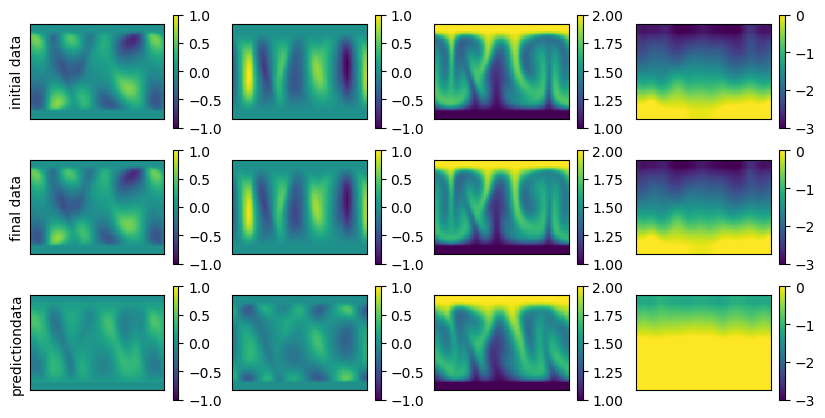

In [242]:
fig, ax = plt.subplots(3,4,figsize=(10,5))
vmins = [-1, -1, 1, -3]
vmaxs = [1, 1, 2,  0]
ax[0,0].set_ylabel("initial data")
ax[1,0].set_ylabel("final data")
ax[2,0].set_ylabel("predictiondata")
for k in range(4):
    plt.colorbar( ax[0,k].matshow( data[idx_start,k].cpu().numpy(), vmin = vmins[k], vmax = vmaxs[k] )  )
    plt.colorbar( ax[1,k].matshow( data[idx_start+n_compare_data,k].cpu().numpy(), vmin = vmins[k], vmax = vmaxs[k] )  )
    plt.colorbar( ax[2,k].matshow( Y[0,k].cpu().numpy(), vmin = vmins[k], vmax = vmaxs[k] )  )
    for j in [0,1,2]:
        ax[j,k].set_xticks([])
        ax[j,k].set_yticks([])